In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
import seaborn as sns

In [2]:
EVALUATION_PATH = '../model_files/'

evals = {}

abs_eval_path = os.path.abspath(EVALUATION_PATH)
for json_file in filter(lambda fn: fn.endswith('.json'), os.listdir(abs_eval_path)):
    evals[json_file] = (pd.read_json(os.path.join(abs_eval_path, json_file)))


BASE_MODELS = {
    'rb': 'Rule-based',
    'lr': 'Logistic Regression',
    'svm': 'Support Vector Machine'
}

df = pd.concat(evals, axis=1).T
df = df.reset_index(names=['model', 'class'])

df['model'] = df['model'].str.removesuffix('.json')
df['base_model'] = df['model'].apply(lambda c: BASE_MODELS.get(c.split('_', maxsplit=1)[0], c.split('_', maxsplit=1)[0]))
df['trained'] = df['model'].str.endswith('_train')
df['is_bert'] = df['model'].str.contains('_bert_')
df['is_bow'] = df['model'].str.contains('_bow_')
df['grouped_split'] = df['model'].str.contains('_g_') | df['model'].str.contains('_g.')
df['grouped_split'] = df['grouped_split'].astype(object)
df.loc[df['base_model'] == 'Rule-based', 'grouped_split'] = np.nan

df['settings_descr'] = df.apply(lambda row: 'Default' if np.isnan(row['grouped_split']) else ('Grouped ' if row['grouped_split'] else 'Non-grouped ')
                                + (' (BERT)' if row['is_bert'] else (' (BoW)' if row['is_bow'] else '')), axis=1)

In [125]:
df

,model,class,precision,recall,f1-score,support,base_model,trained,is_bert,is_bow,grouped_split,settings_descr
0,lr_bert_g_perf_train,ack,0.025641,0.250000,0.046512,4.000000,Logistic Regression,True,True,False,True,Grouped (BERT)
1,lr_bert_g_perf_train,affirm,0.937008,0.700000,0.801347,170.000000,Logistic Regression,True,True,False,True,Grouped (BERT)
2,lr_bert_g_perf_train,bye,0.096970,1.000000,0.176796,16.000000,Logistic Regression,True,True,False,True,Grouped (BERT)
3,lr_bert_g_perf_train,confirm,0.511111,1.000000,0.676471,23.000000,Logistic Regression,True,True,False,True,Grouped (BERT)
4,lr_bert_g_perf_train,deny,0.114286,1.000000,0.205128,4.000000,Logistic Regression,True,True,False,True,Grouped (BERT)
...,...,...,...,...,...,...,...,...,...,...,...,...
157,svm_bow_perf_train,restart,1.000000,1.000000,1.000000,1.000000,Support Vector Machine,True,False,True,False,Non-grouped (BoW)
158,svm_bow_perf_train,thankyou,0.995902,0.997947,0.996923,487.000000,Support Vector Machine,True,False,True,False,Non-grouped (BoW)
159,svm_bow_perf_train,accuracy,0.984722,0.984722,0.984722,0.984722,Support Vector Machine,True,False,True,False,Non-grouped (BoW)
160,svm_bow_perf_train,macro avg,0.904067,0.883926,0.878824,3600.000000,Support Vector Machine,True,False,True,False,Non-grouped (BoW)


In [127]:
accuracy = df[df['class'] == 'accuracy']
#accuracy = accuracy.drop(['class', 'recall', 'f1-score'], axis=1)
accuracy = accuracy.rename({'precision': 'accuracy'}, axis=1)

macro_avg = df[df['class'] == 'macro avg']
#macro_avg = macro_avg.drop(['class', 'precision', 'f1-score'], axis=1)
macro_avg = macro_avg.rename({'recall': 'balanced_accuracy'}, axis=1)

weighted_avg = df[df['class'] == 'weighted avg']

classes = df[~df['class'].isin(['accuracy', 'macro avg', 'weighted avg'])]
classes

,model,class,precision,recall,f1-score,support,base_model,trained,is_bert,is_bow,grouped_split,settings_descr
0,lr_bert_g_perf_train,ack,0.025641,0.250000,0.046512,4.0,Logistic Regression,True,True,False,True,Grouped (BERT)
1,lr_bert_g_perf_train,affirm,0.937008,0.700000,0.801347,170.0,Logistic Regression,True,True,False,True,Grouped (BERT)
2,lr_bert_g_perf_train,bye,0.096970,1.000000,0.176796,16.0,Logistic Regression,True,True,False,True,Grouped (BERT)
3,lr_bert_g_perf_train,confirm,0.511111,1.000000,0.676471,23.0,Logistic Regression,True,True,False,True,Grouped (BERT)
4,lr_bert_g_perf_train,deny,0.114286,1.000000,0.205128,4.0,Logistic Regression,True,True,False,True,Grouped (BERT)
...,...,...,...,...,...,...,...,...,...,...,...,...
154,svm_bow_perf_train,reqalts,0.964000,0.983673,0.973737,245.0,Support Vector Machine,True,False,True,False,Non-grouped (BoW)
155,svm_bow_perf_train,reqmore,0.500000,1.000000,0.666667,1.0,Support Vector Machine,True,False,True,False,Non-grouped (BoW)
156,svm_bow_perf_train,request,0.992521,0.994647,0.993583,934.0,Support Vector Machine,True,False,True,False,Non-grouped (BoW)
157,svm_bow_perf_train,restart,1.000000,1.000000,1.000000,1.0,Support Vector Machine,True,False,True,False,Non-grouped (BoW)


## Comparing accuracy of the models

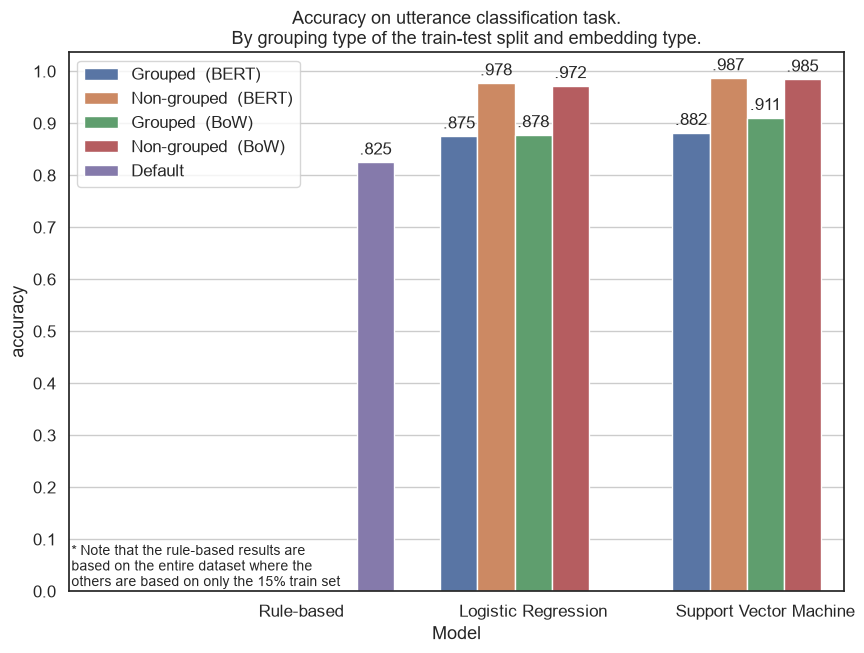

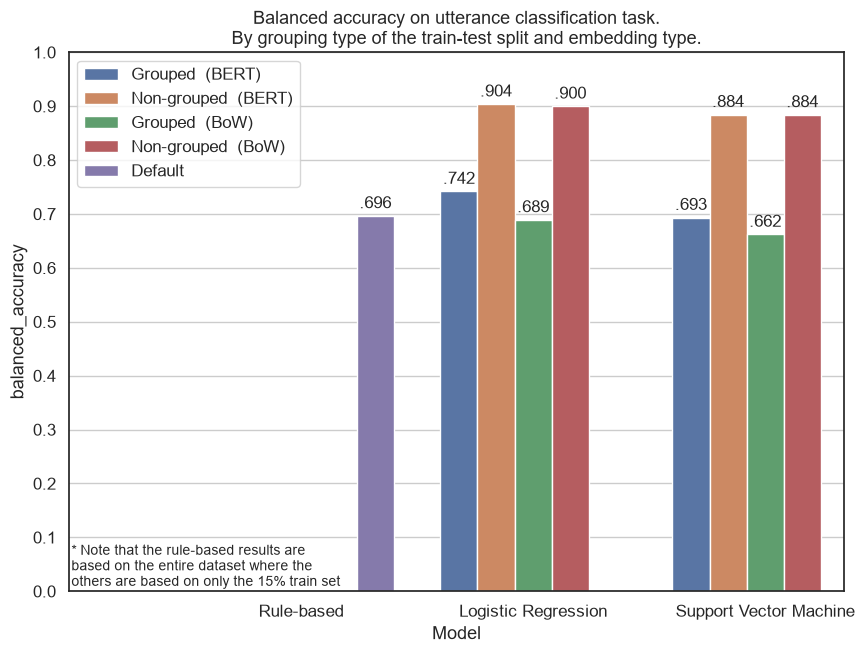

In [123]:
from matplotlib.container import BarContainer

def model_wide_barplot(df, col, name):
    model_order = ['Rule-based', 'Logistic Regression', 'Support Vector Machine']

    sns.set_theme(style="white", palette="deep", font_scale=1.1)
    plt.figure(figsize=(10, 7))

    ax = sns.barplot(
        df,
        x='base_model',
        y=col,
        hue='settings_descr',
        order=model_order,
    )

    ax.autoscale_view()
    sns.move_legend(ax, 'upper left')
    ax.set_xlim(-1)
    ax.legend_.set_title(None)

    for container in ax.containers:
        if isinstance(container, BarContainer):
            labels = [
                f'{patch.get_height():.3f}'.lstrip('0')
                for patch in container
            ]
            ax.bar_label(container, labels=labels, padding=3, fontsize=12)


    plt.text(-0.99, .01, fontdict={'fontsize': 10},
            s="* Note that the rule-based results are\nbased on the entire dataset where the \nothers are based on only the 15% train set")

    plt.title(f"""{name} on utterance classification task.
    By grouping type of the train-test split and embedding type.""")
    plt.xlabel('Model')
    plt.yticks(np.arange(0, 1.05, 0.1))
    plt.yticks(np.arange(0, 1.05, 0.05), minor=True)
    plt.grid(axis='y')

model_wide_barplot(accuracy, 'accuracy', 'Accuracy')
model_wide_barplot(macro_avg, 'balanced_accuracy', 'Balanced accuracy')

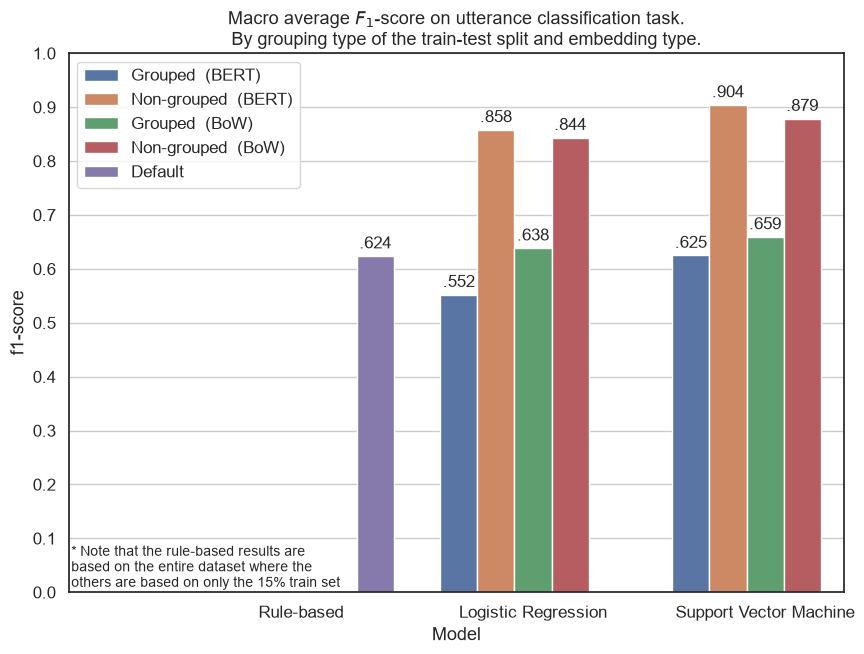

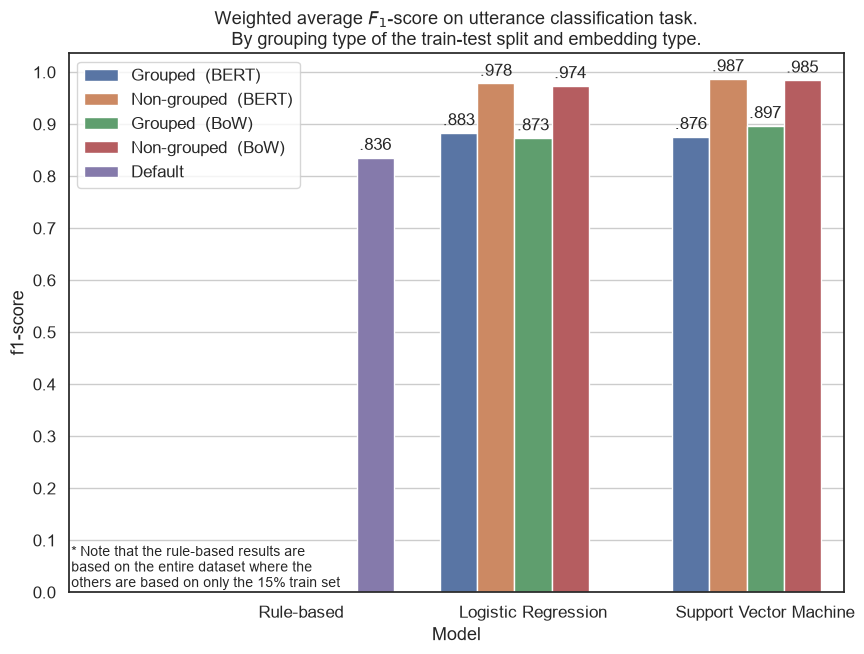

In [130]:
model_wide_barplot(macro_avg, 'f1-score', 'Macro average $F_1$-score')
model_wide_barplot(weighted_avg, 'f1-score', 'Weighted average $F_1$-score')

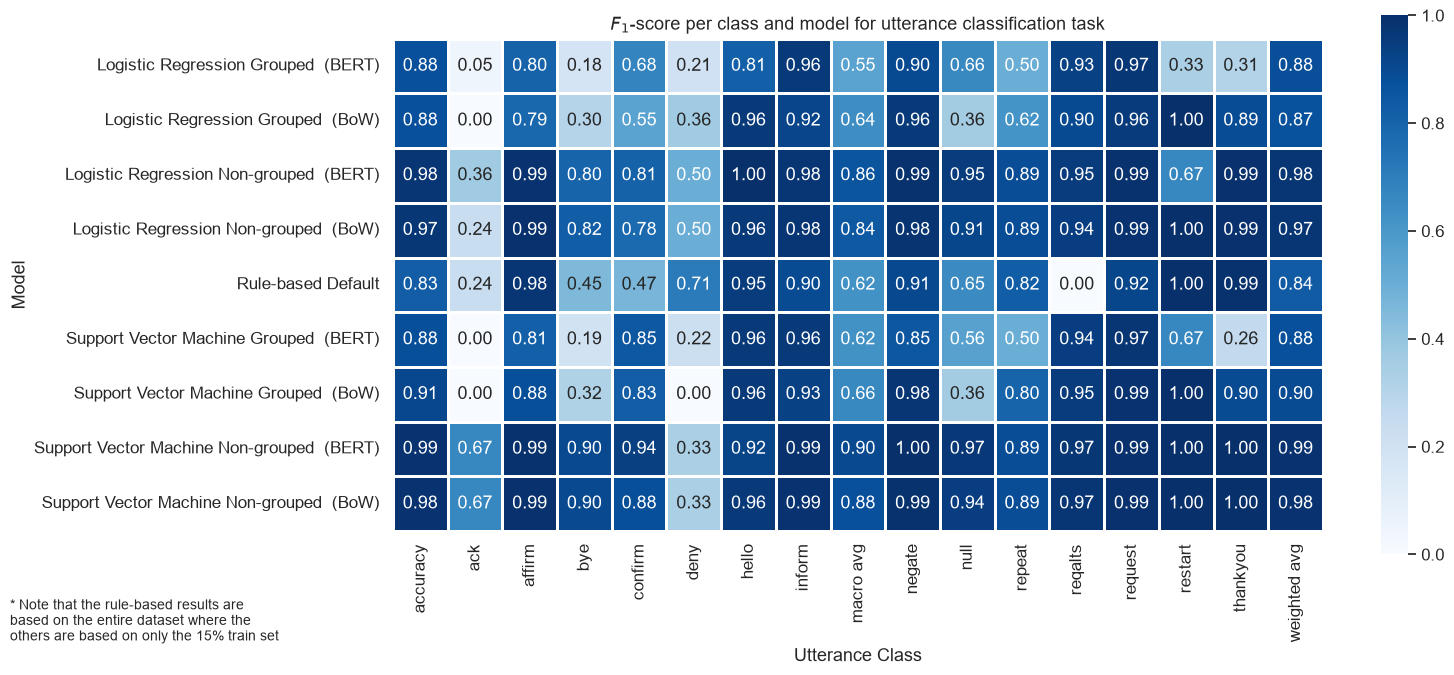

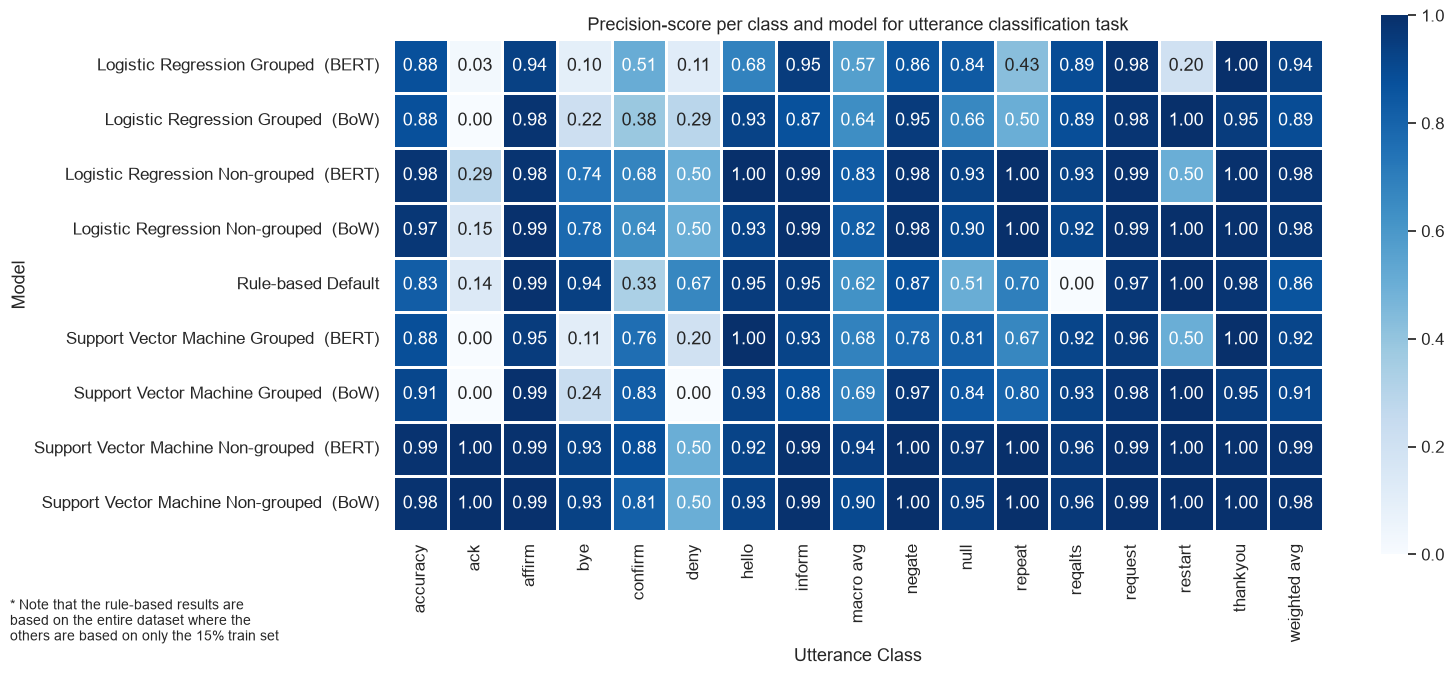

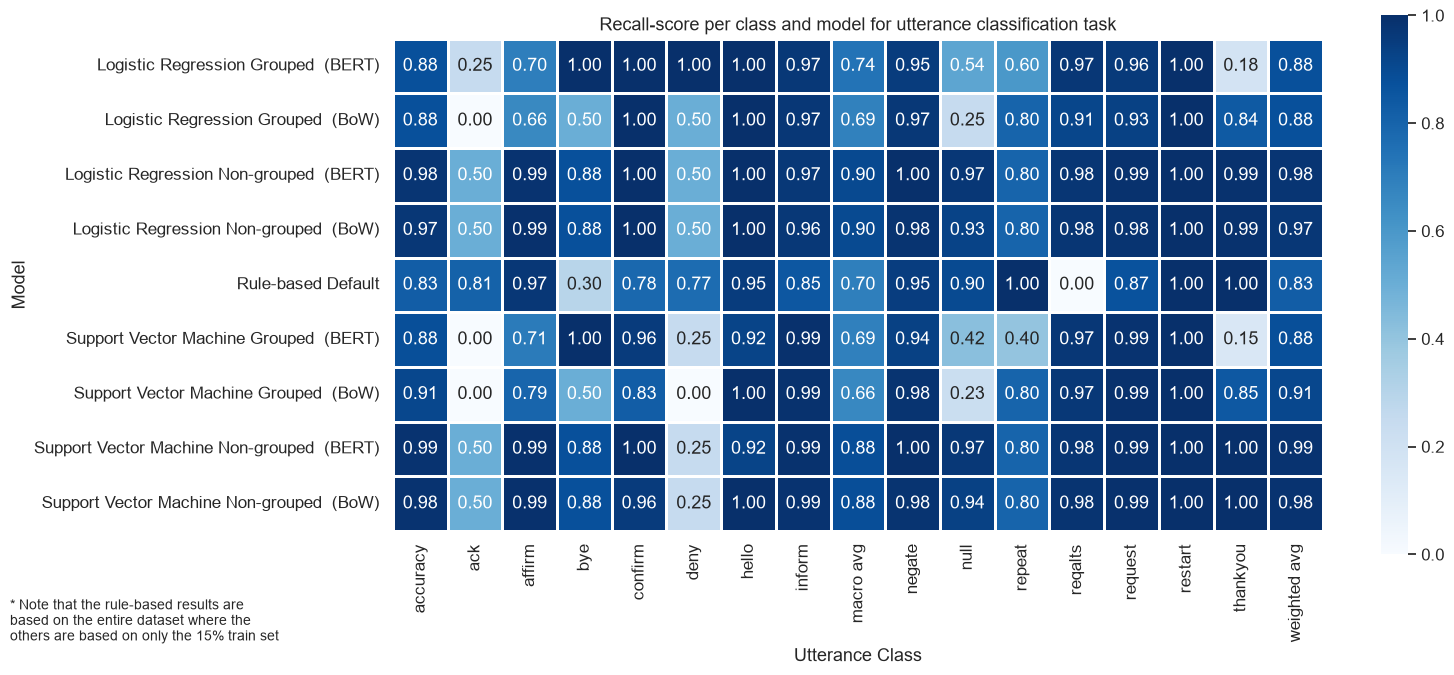

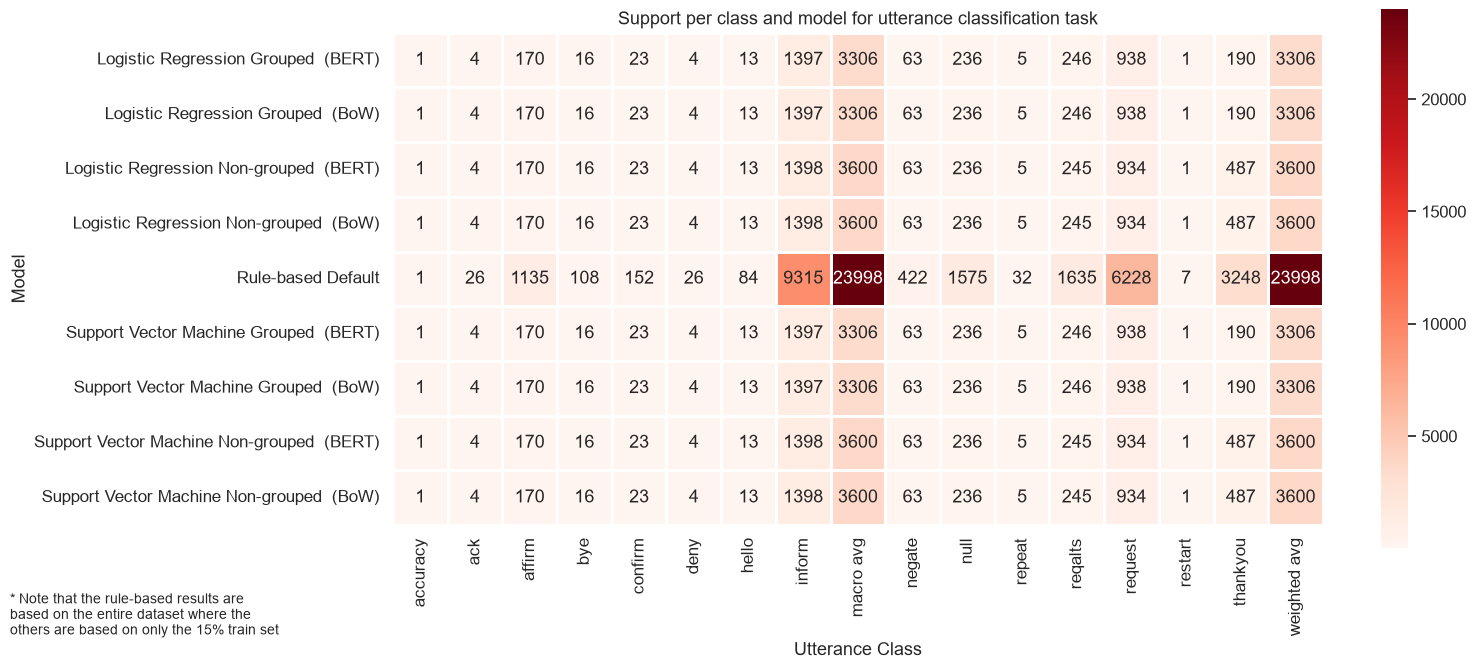

In [136]:
def plot_param(col_name, title_name, fmt='.2f', cmap='Blues'):
    f1_table = (
        df.assign(
            model_settings=df['base_model'] + ' ' + df['settings_descr']
        )
        .pivot_table(
            index='class',
            columns='model_settings',
            values=col_name
        )
        .sort_index()
    ).dropna()

    #print(f1_table.to_latex(float_format="%.3f"))
    plt.figure(figsize=(15, 7))
    sns.heatmap(f1_table.T, cmap=cmap, fmt=fmt, annot=True, linewidths=2, square=True)
    plt.title(title_name + " per class and model for utterance classification task")
    plt.text(-7, 11, fontdict={'fontsize': 10},
            s="* Note that the rule-based results are\nbased on the entire dataset where the \nothers are based on only the 15% train set")

    plt.xlabel("Utterance Class")
    plt.ylabel("Model")
    
plot_param('f1-score', '$F_1$-score')
plot_param('precision','Precision-score')
plot_param('recall','Recall-score')
plot_param('support','Support', '.0f', 'Reds')